In [1]:
# external
import numpy as np
import healpy as hp
# modules from cmblensplus
import cmblensplus.curvedsky as cs
import constant as c
import cmb
from matplotlib.pyplot import *

In [2]:
import cmblensplus.curvedsky.libcurvedsky as libcs

In [3]:
Lmax = 1024*2
# ucl is an array of shape [0:5,0:rlmax+1] and ucl[0,:] = TT, ucl[1,:] = EE, ucl[2,:] = TE, lcl[3,:] = phiphi, lcl[4,:] = Tphi
lcl = cmb.read_camb_cls('../data/lensedcls.dat',ftype='lens',output='array')[:,:Lmax+1]

In [4]:
alm = cs.utils.gaussTEB(lcl[0,:],lcl[1,:],lcl[2,:],lcl[3,:])

In [5]:
Tmap = cs.utils.hp_alm2map(1024,alm[0])

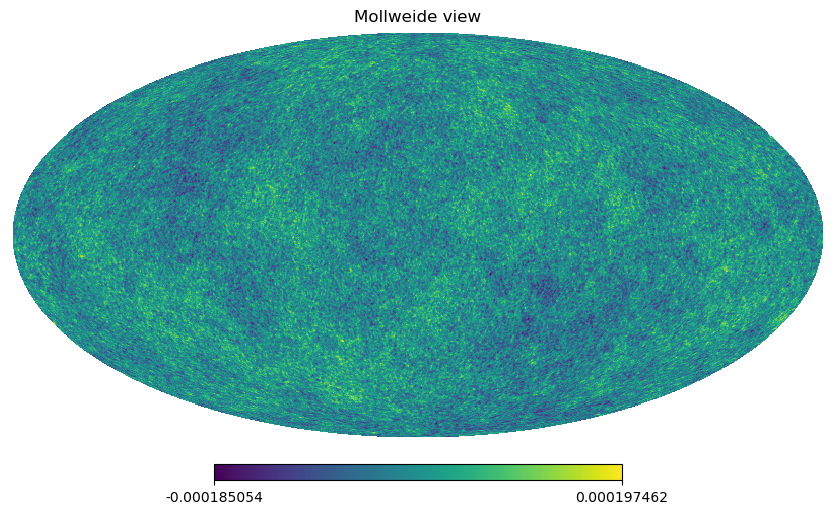

In [6]:
hp.mollview(Tmap)

In [7]:
Talm = cs.utils.hp_map2alm(Lmax,Lmax,Tmap)

In [8]:
cl = cs.utils.alm2cl(Talm)

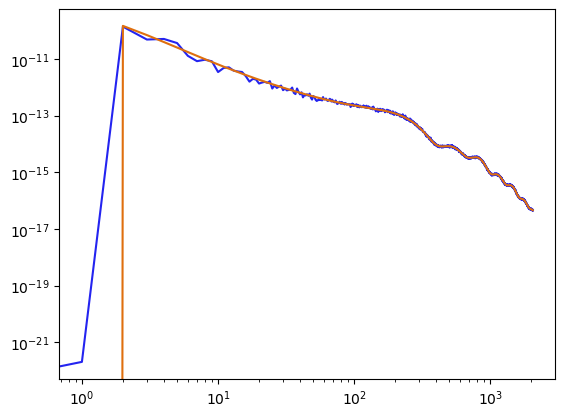

In [9]:
loglog(cl)
loglog(lcl[0])

In [10]:
QU = cs.utils.hp_alm2map_spin(1024,2,alm[1],alm[2])

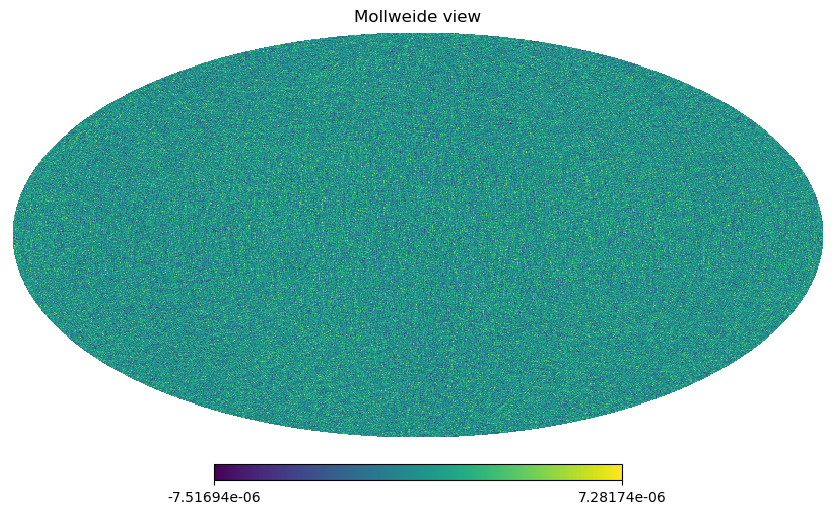

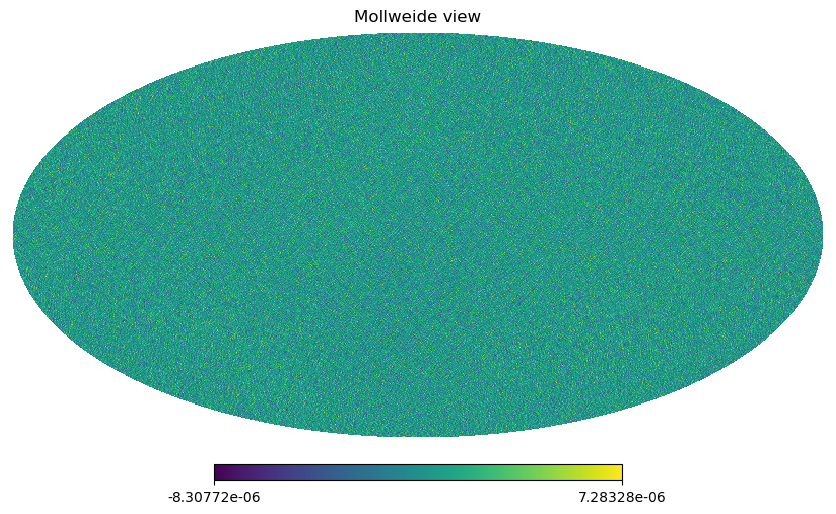

In [11]:
hp.mollview(QU[0])
hp.mollview(QU[1])

In [12]:
Elm, Blm = cs.utils.hp_map2alm_spin(Lmax,Lmax,2,QU[0],QU[1])

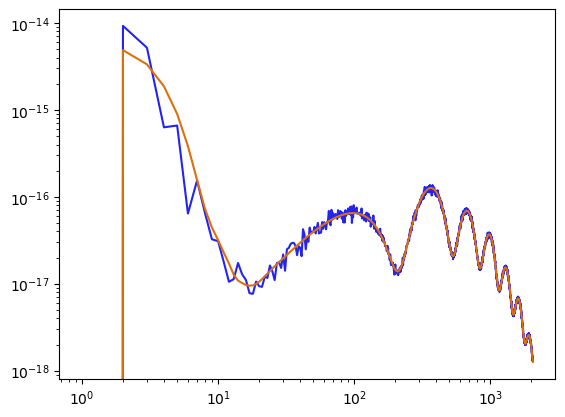

In [13]:
EE = cs.utils.alm2cl(Elm)
loglog(EE)
loglog(lcl[1])

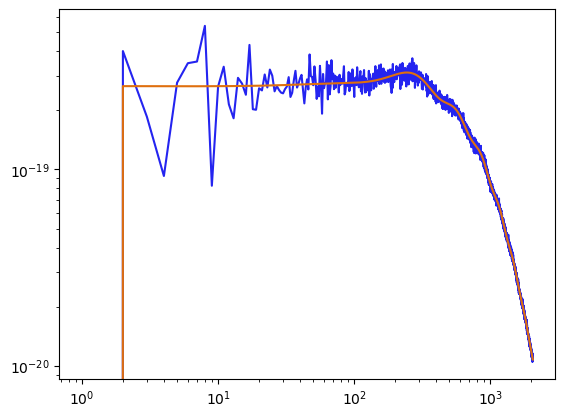

In [14]:
BB = cs.utils.alm2cl(Blm)
loglog(BB)
loglog(lcl[2])